# Lawgic Taxonomy Legal-BERT Fine-Tuning

This notebook trains `nlpaueb/legal-bert-base-uncased` on the fused 3-source Lawgic taxonomy dataset at `generated_files/lawgic_taxonomy/lawgic_combined_wide.csv`.

It replaces the older ToS;DR-only pipeline with a multi-label classifier over the curated Lawgic taxonomy. The key change is masked Binary Cross-Entropy: labels only contribute loss where the source data says a topic was observed or explicitly evaluated. This avoids treating unknown labels as negatives.

Outputs are written to `saved_models/lawgic_classifier_legal-bert_v2/` and include the model, tokenizer, test metrics, thresholds, and a filtered 44-topic taxonomy copy. The original taxonomy has 45 topics, but `unclassified` is intentionally excluded because it is a fallback bucket rather than a reliable supervised signal.

Companion documentation: `docs/lawgic_taxonomy_finetuning.md`.

## 1. Environment Imports and Experiment Configuration

This cell centralizes imports, paths, and experiment constants. The resolved baseline uses raw `text`, keeps the previous Legal-BERT hyperparameters, drops the `unclassified` fallback topic, and writes artifacts to a v2 model directory so previous experiments are not overwritten.

In [2]:
import inspect
import json
import random
import shutil
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
MAX_LENGTH = 256
DECISION_THRESHOLD = 0.50
TRAIN_SIZE = 0.80
VAL_SIZE = 0.10
TEST_SIZE = 0.10
SPLIT_STRATEGY = "stratified"

LEARNING_RATE = 3e-5
MAX_EPOCHS = 20
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 3
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06

TOTAL_TAXONOMY_TOPICS = 45
EXCLUDED_TOPIC_IDS = {"unclassified"}
NUM_LAWGIC_TOPICS = 44
TEXT_COLUMN = "text"


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    sentinel = Path("generated_files/lawgic_taxonomy/lawgic_combined_wide.csv")
    for candidate in (start, *start.parents):
        if (candidate / sentinel).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root containing {sentinel}")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "generated_files/lawgic_taxonomy/lawgic_combined_wide.csv"
TAXONOMY_PATH = PROJECT_ROOT / "generated_files/lawgic_taxonomy/lawgic_topics.json"
FUSION_SUMMARY_PATH = PROJECT_ROOT / "generated_files/lawgic_taxonomy/lawgic_fusion_summary.json"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "saved_models/lawgic_classifier_legal-bert_v2"
CHECKPOINT_DIR = MODEL_OUTPUT_DIR / "checkpoints"

random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Training data: {DATA_PATH}")
print(f"Taxonomy: {TAXONOMY_PATH}")
print(f"Model output: {MODEL_OUTPUT_DIR}")
print(f"Text column: {TEXT_COLUMN}")
print(f"Excluded topics: {sorted(EXCLUDED_TOPIC_IDS)}")

Project root: C:\Users\Enrique\Coding Projects\Thesis\lawgic
Training data: C:\Users\Enrique\Coding Projects\Thesis\lawgic\generated_files\lawgic_taxonomy\lawgic_combined_wide.csv
Taxonomy: C:\Users\Enrique\Coding Projects\Thesis\lawgic\generated_files\lawgic_taxonomy\lawgic_topics.json
Model output: C:\Users\Enrique\Coding Projects\Thesis\lawgic\saved_models\lawgic_classifier_legal-bert_v2
Text column: text
Excluded topics: ['unclassified']


## 2. Hardware Device Autodetection and Precision Policy

The same notebook should run on CUDA, Apple Silicon MPS, or CPU. CUDA uses `fp16=True`; MPS and CPU stay in full precision for stability. Hugging Face `Trainer` handles device placement internally.

In [3]:
def detect_device() -> tuple[str, torch.device]:
    if torch.cuda.is_available():
        return "cuda", torch.device("cuda")
    if torch.backends.mps.is_available():
        return "mps", torch.device("mps")
    return "cpu", torch.device("cpu")


DEVICE_TYPE, DEVICE = detect_device()
USE_FP16 = DEVICE_TYPE == "cuda"
USE_BF16 = False

if DEVICE_TYPE == "cuda":
    torch.set_float32_matmul_precision("high")
    DEVICE_NAME = torch.cuda.get_device_name(0)
elif DEVICE_TYPE == "mps":
    DEVICE_NAME = "Apple Silicon MPS"
else:
    DEVICE_NAME = "CPU"

print(f"Selected device: {DEVICE_TYPE} ({DEVICE_NAME})")
print(f"Training precision: fp16={USE_FP16}, bf16={USE_BF16}")

Selected device: cuda (NVIDIA GeForce RTX 4060 Laptop GPU)
Training precision: fp16=True, bf16=False


## 3. Taxonomy Loading

The taxonomy JSON is the source of truth for label ordering. We load all 45 topics, then remove `unclassified` and build compact 44-topic mappings. This preserves canonical order while ensuring the classifier head never learns the fallback bucket.

In [4]:
with TAXONOMY_PATH.open("r", encoding="utf-8") as file:
    taxonomy_payload = json.load(file)

all_topics = taxonomy_payload["topics"]
original_topic_ids = [topic["id"] for topic in all_topics]
if len(original_topic_ids) != TOTAL_TAXONOMY_TOPICS:
    raise ValueError(f"Expected {TOTAL_TAXONOMY_TOPICS} taxonomy topics, found {len(original_topic_ids)}")

excluded_indices = [idx for idx, topic_id in enumerate(original_topic_ids) if topic_id in EXCLUDED_TOPIC_IDS]
keep_indices = [idx for idx, topic_id in enumerate(original_topic_ids) if topic_id not in EXCLUDED_TOPIC_IDS]
training_topics = [all_topics[idx] for idx in keep_indices]
topic_ids = [topic["id"] for topic in training_topics]

if len(topic_ids) != NUM_LAWGIC_TOPICS:
    raise ValueError(f"Expected {NUM_LAWGIC_TOPICS} training topics, found {len(topic_ids)}")
if not excluded_indices:
    raise ValueError(f"No excluded topics found for {EXCLUDED_TOPIC_IDS}")

original_to_compact_index = {original_idx: compact_idx for compact_idx, original_idx in enumerate(keep_indices)}
compact_to_original_index = {compact_idx: original_idx for original_idx, compact_idx in original_to_compact_index.items()}
id2label = {idx: topic_id for idx, topic_id in enumerate(topic_ids)}
label2id = {topic_id: idx for idx, topic_id in id2label.items()}
parent_by_topic = {topic["id"]: topic["parent_topic"] for topic in training_topics}
name_by_topic = {topic["id"]: topic["name"] for topic in training_topics}

training_taxonomy = {
    "schema_version": taxonomy_payload.get("$schema_version", taxonomy_payload.get("schema_version", "1.0.0")),
    "source_taxonomy_path": str(TAXONOMY_PATH.relative_to(PROJECT_ROOT)),
    "excluded_topic_ids": sorted(EXCLUDED_TOPIC_IDS),
    "original_num_topics": len(original_topic_ids),
    "num_training_topics": len(topic_ids),
    "topics": [
        {
            **topic,
            "original_topic_index": compact_to_original_index[compact_idx],
            "classifier_id": compact_idx,
        }
        for compact_idx, topic in enumerate(training_topics)
    ],
    "parent_topics": [
        parent
        for parent in taxonomy_payload.get("parent_topics", [])
        if parent.get("id") not in EXCLUDED_TOPIC_IDS
    ],
    "label2id": label2id,
    "id2label": {str(idx): label for idx, label in id2label.items()},
}

topic_table = pd.DataFrame(
    {
        "classifier_id": range(len(topic_ids)),
        "original_index": keep_indices,
        "topic_id": topic_ids,
        "name": [name_by_topic[topic_id] for topic_id in topic_ids],
        "parent_topic": [parent_by_topic[topic_id] for topic_id in topic_ids],
    }
)

print(f"Original topics: {len(original_topic_ids)}")
print(f"Training topics: {len(topic_ids)}")
print(f"Excluded topic indices: {excluded_indices}")
display(topic_table)

Original topics: 45
Training topics: 44
Excluded topic indices: [44]


,classifier_id,original_index,topic_id,name,parent_topic
0,0,0,choice_of_law,Choice of Law,dispute_resolution
1,1,1,choice_of_forum,Choice of Forum,dispute_resolution
2,2,2,mandatory_arbitration,Mandatory Arbitration,dispute_resolution
3,3,3,class_action_waiver,Class Action Waiver,dispute_resolution
4,4,4,limitation_of_liability,Limitation of Liability,limitation_of_remedies
5,5,5,liability_cap,Liability Cap,limitation_of_remedies
6,6,6,warranty_disclaimer,Warranty Disclaimer,limitation_of_remedies
7,7,7,indemnification,Indemnification,limitation_of_remedies
8,8,8,limitation_period,Limitation Period,limitation_of_remedies
9,9,9,contract_changes,Contract Changes,unilateral_modification


## 4. Data Loading and Validation

The wide CSV already contains one row per normalized clause and JSON-encoded 45-topic vectors. We parse those fields, validate original vector lengths, then slice out `unclassified` to create compact 44-topic label, mask, and score vectors.

In [5]:
JSON_COLUMNS = [
    "sources",
    "labels_presence",
    "mask",
    "scores",
    "topic_scores",
    "active_topic_ids",
    "conflict_topic_ids",
    "native_annotations",
]
REQUIRED_COLUMNS = [TEXT_COLUMN, "normalized_text", "has_score_conflict", *JSON_COLUMNS]


def parse_json_value(value: Any) -> Any:
    if pd.isna(value):
        return None
    if isinstance(value, str):
        return json.loads(value)
    return value


def compact_vector(vector: list[Any], fill_value: float | None = None) -> list[Any]:
    if len(vector) != TOTAL_TAXONOMY_TOPICS:
        raise ValueError(f"Expected vector length {TOTAL_TAXONOMY_TOPICS}, found {len(vector)}")
    compact = [vector[idx] for idx in keep_indices]
    if fill_value is not None:
        compact = [fill_value if value is None else value for value in compact]
    return compact


def source_counts(source_lists: pd.Series) -> pd.Series:
    counter = Counter(source for sources in source_lists for source in sources)
    return pd.Series(counter).sort_values(ascending=False)


raw_df = pd.read_csv(DATA_PATH)
missing_columns = [column for column in REQUIRED_COLUMNS if column not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in {DATA_PATH}: {missing_columns}")

samples_df = raw_df.copy()
for column in JSON_COLUMNS:
    samples_df[column] = samples_df[column].map(parse_json_value)

samples_df[TEXT_COLUMN] = samples_df[TEXT_COLUMN].astype("string").str.strip()
samples_df["normalized_text"] = samples_df["normalized_text"].astype("string").str.strip()
before_text_filter = len(samples_df)
samples_df = samples_df.dropna(subset=[TEXT_COLUMN])
samples_df = samples_df[samples_df[TEXT_COLUMN] != ""].copy()

for vector_column in ["labels_presence", "mask", "scores"]:
    bad_lengths = samples_df[vector_column].map(len).ne(TOTAL_TAXONOMY_TOPICS)
    if bad_lengths.any():
        raise ValueError(f"{vector_column} contains {bad_lengths.sum()} non-{TOTAL_TAXONOMY_TOPICS}-length vectors")

samples_df["labels"] = samples_df["labels_presence"].map(lambda values: compact_vector(values, fill_value=0.0))
samples_df["label_mask"] = samples_df["mask"].map(lambda values: compact_vector(values, fill_value=0.0))
samples_df["scores_44"] = samples_df["scores"].map(lambda values: compact_vector(values))
samples_df["active_topic_ids_44"] = samples_df["active_topic_ids"].map(
    lambda values: [topic_id for topic_id in values if topic_id not in EXCLUDED_TOPIC_IDS]
)
samples_df["conflict_topic_ids_44"] = samples_df["conflict_topic_ids"].map(
    lambda values: [topic_id for topic_id in values if topic_id not in EXCLUDED_TOPIC_IDS]
)
samples_df["label_count"] = samples_df["labels"].map(lambda values: int(np.sum(values)))
samples_df["mask_count"] = samples_df["label_mask"].map(lambda values: int(np.sum(values)))
samples_df["source_count"] = samples_df["sources"].map(len)

label_matrix = np.vstack(samples_df["labels"].to_numpy()).astype(np.float32)
mask_matrix = np.vstack(samples_df["label_mask"].to_numpy()).astype(np.float32)
positive_counts = label_matrix.sum(axis=0).astype(int)
mask_counts = mask_matrix.sum(axis=0).astype(int)

if label_matrix.shape[1] != NUM_LAWGIC_TOPICS or mask_matrix.shape[1] != NUM_LAWGIC_TOPICS:
    raise ValueError("Compacted label/mask matrices do not match NUM_LAWGIC_TOPICS")

with FUSION_SUMMARY_PATH.open("r", encoding="utf-8") as file:
    fusion_summary = json.load(file)

source_distribution = source_counts(samples_df["sources"])
topic_distribution = pd.DataFrame(
    {
        "classifier_id": range(NUM_LAWGIC_TOPICS),
        "topic_id": topic_ids,
        "name": [name_by_topic[topic_id] for topic_id in topic_ids],
        "parent_topic": [parent_by_topic[topic_id] for topic_id in topic_ids],
        "positive_count": positive_counts,
        "mask_count": mask_counts,
    }
).sort_values("positive_count", ascending=False)

print(f"Raw rows: {len(raw_df):,}")
print(f"Rows after empty-text filter: {len(samples_df):,} (dropped {before_text_filter - len(samples_df):,})")
print(f"Fusion summary wide rows: {fusion_summary.get('num_wide_rows'):,}")
print(f"Training labels: {NUM_LAWGIC_TOPICS}")
print(f"Multi-label rows: {(samples_df['label_count'] > 1).sum():,}")
print(f"Rows with score conflicts: {samples_df['has_score_conflict'].sum():,}")
print(f"Fusion summary conflict rows: {fusion_summary.get('num_conflict_rows'):,}")
print("\nRows by source membership:")
display(source_distribution.rename("rows"))
display(topic_distribution.head(15))

Raw rows: 26,479
Rows after empty-text filter: 26,479 (dropped 0)
Fusion summary wide rows: 26,479
Training labels: 44
Multi-label rows: 12,723
Rows with score conflicts: 47
Fusion summary conflict rows: 60

Rows by source membership:


tos_dr       21949
claudette     3182
100_tos       1460
Name: rows, dtype: int64

,classifier_id,topic_id,name,parent_topic,positive_count,mask_count
17,17,contract_by_use,Contract Formed Through Use,consent_contract_formation,3684,3684
34,34,complaint_system,Complaint Handling System,user_rights_consumer_protection,3596,3596
40,40,governance,Service Governance,service_governance,3318,3318
16,16,content_removal,Content Removal,enforcement_actions,2676,2676
18,18,privacy_incorporation,Privacy Policy Incorporation,consent_contract_formation,2561,2561
26,26,trackers,Trackers,privacy_data_governance,2465,2465
36,36,discretionary_interpretation,Discretionary Interpretation,interpretation_legal_structure,2433,2433
14,14,account_termination,Account Termination,enforcement_actions,1972,1972
6,6,warranty_disclaimer,Warranty Disclaimer,limitation_of_remedies,1622,1622
25,25,personal_data,Personal Data,privacy_data_governance,1563,1563


## 5. Exploratory Data Analysis

These plots sanity-check the fused dataset before training: topic imbalance, source mix, topic coverage by source, token length distribution, and multi-label density.

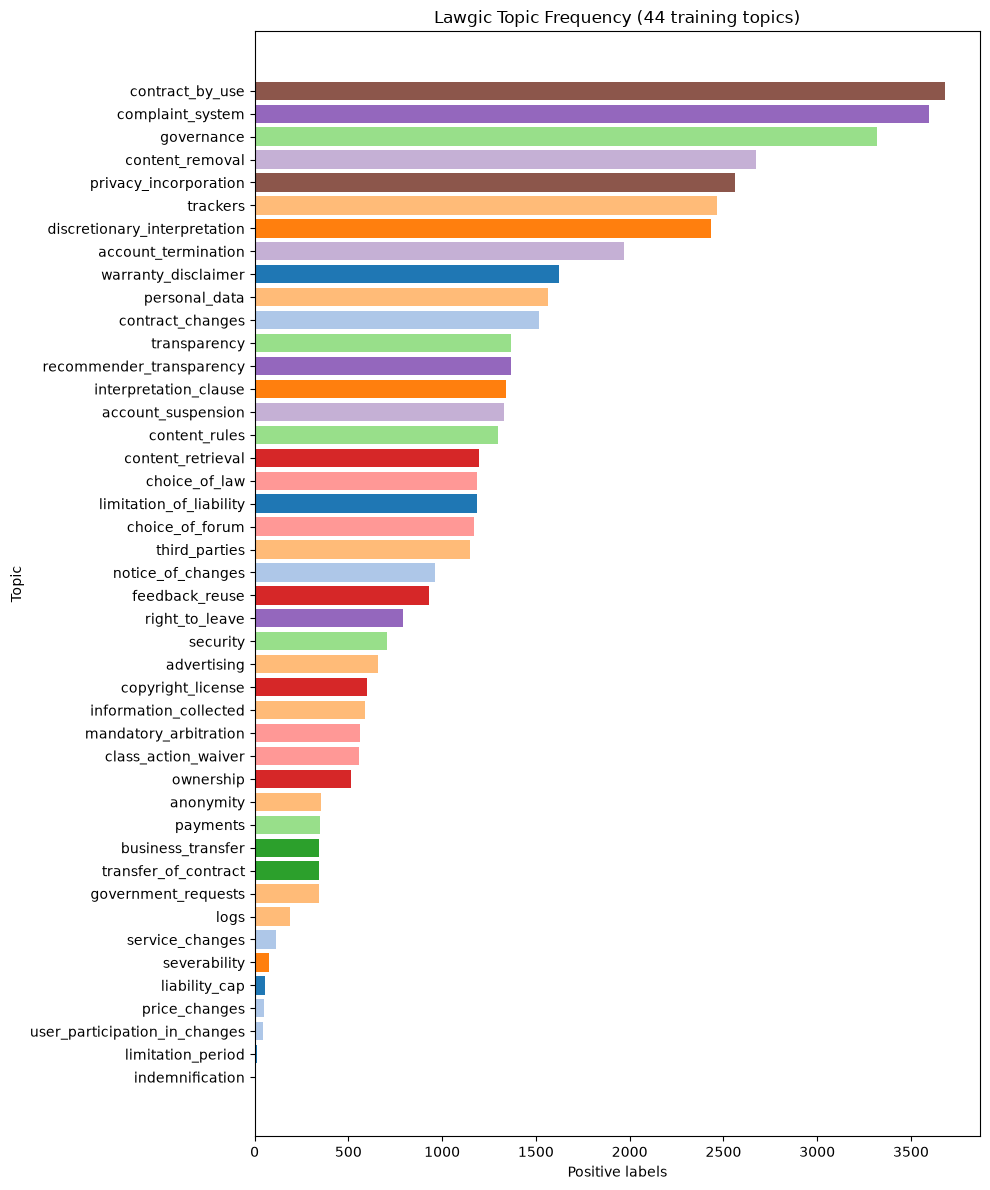

,source,rows
2,tos_dr,21949
1,claudette,3182
0,100_tos,1460
3,multi_source,109


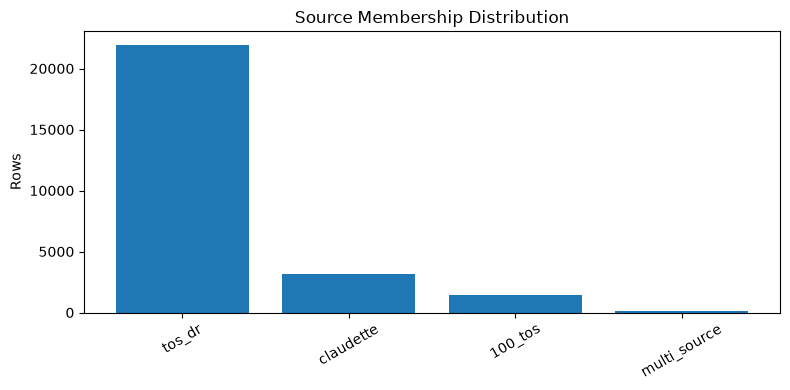

In [6]:
topic_plot_df = topic_distribution.sort_values("positive_count", ascending=True)
parent_ids = topic_plot_df["parent_topic"].unique().tolist()
color_map = {parent: plt.cm.tab20(idx % 20) for idx, parent in enumerate(parent_ids)}
colors = topic_plot_df["parent_topic"].map(color_map)

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(topic_plot_df["topic_id"], topic_plot_df["positive_count"], color=colors)
ax.set_title("Lawgic Topic Frequency (44 training topics)")
ax.set_xlabel("Positive labels")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()

source_rows = []
for source in sorted({source for sources in samples_df["sources"] for source in sources}):
    source_rows.append({"source": source, "rows": int(samples_df["sources"].map(lambda values: source in values).sum())})
source_rows.append({"source": "multi_source", "rows": int((samples_df["source_count"] > 1).sum())})
source_plot_df = pd.DataFrame(source_rows).sort_values("rows", ascending=False)
display(source_plot_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(source_plot_df["source"], source_plot_df["rows"])
ax.set_title("Source Membership Distribution")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

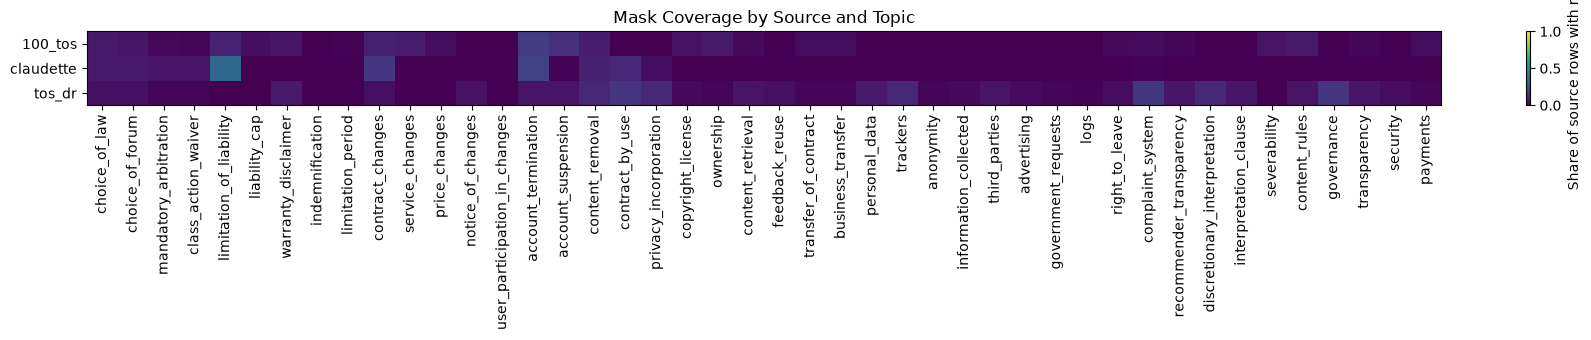

Token indices sequence length is longer than the specified maximum sequence length for this model (579 > 512). Running this sequence through the model will result in indexing errors


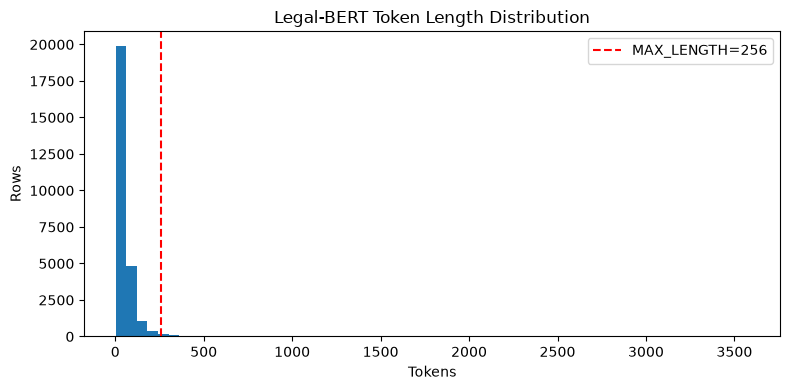

count    26479.000000
mean        52.856150
std         61.640041
min          3.000000
50%         38.000000
75%         62.000000
90%        101.000000
95%        137.000000
99%        268.000000
max       3579.000000
Name: token_length, dtype: float64

label_count
1    13756
2     6405
3     2714
4     3577
5       24
6        3
Name: rows_with_active_topic_count, dtype: int64

In [7]:
source_names = sorted({source for sources in samples_df["sources"] for source in sources})
coverage_rows = []
for source in source_names:
    source_mask = samples_df["sources"].map(lambda values: source in values).to_numpy()
    source_topic_mask = mask_matrix[source_mask]
    coverage = source_topic_mask.mean(axis=0) if source_topic_mask.size else np.zeros(NUM_LAWGIC_TOPICS)
    for idx, topic_id in enumerate(topic_ids):
        coverage_rows.append({"source": source, "topic_id": topic_id, "mask_coverage": coverage[idx]})

coverage_df = pd.DataFrame(coverage_rows)
coverage_pivot = coverage_df.pivot(index="source", columns="topic_id", values="mask_coverage").loc[source_names, topic_ids]

fig, ax = plt.subplots(figsize=(18, 3.5))
image = ax.imshow(coverage_pivot.to_numpy(), aspect="auto", vmin=0, vmax=1)
ax.set_title("Mask Coverage by Source and Topic")
ax.set_yticks(range(len(source_names)), labels=source_names)
ax.set_xticks(range(NUM_LAWGIC_TOPICS), labels=topic_ids, rotation=90)
fig.colorbar(image, ax=ax, label="Share of source rows with mask=1")
plt.tight_layout()
plt.show()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
token_lengths = [len(tokenizer.encode(text, add_special_tokens=True, truncation=False)) for text in samples_df[TEXT_COLUMN].astype(str)]
samples_df["token_length"] = token_lengths

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(token_lengths, bins=60)
ax.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"MAX_LENGTH={MAX_LENGTH}")
ax.set_title("Legal-BERT Token Length Distribution")
ax.set_xlabel("Tokens")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
plt.show()

length_summary = pd.Series(token_lengths).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
display(length_summary.rename("token_length"))

axt = samples_df["label_count"].value_counts().sort_index()
display(axt.rename("rows_with_active_topic_count"))

## 6. Train, Validation, and Test Split

The default split is 80/10/10 and stratifies by the first active non-`unclassified` topic. This is a practical multi-label baseline. A stricter group split is deferred until a stable service/company key is extracted from the fused metadata.

In [8]:
def primary_stratify_label(active_topic_ids: list[str]) -> str:
    for topic_id in active_topic_ids:
        if topic_id in label2id:
            return topic_id
    return "no_active_topic"


def stratify_or_none(labels: pd.Series) -> pd.Series | None:
    counts = labels.value_counts()
    if len(counts) < 2 or counts.min() < 2:
        print("Stratification disabled because at least one bucket has fewer than two rows.")
        return None
    return labels


def make_stratified_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    stratify_labels = df["stratify_topic"]
    train_val_df, test_df = train_test_split(
        df,
        test_size=TEST_SIZE,
        random_state=SEED,
        shuffle=True,
        stratify=stratify_or_none(stratify_labels),
    )
    relative_val_size = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=relative_val_size,
        random_state=SEED,
        shuffle=True,
        stratify=stratify_or_none(train_val_df["stratify_topic"]),
    )
    return train_df.copy(), val_df.copy(), test_df.copy()


samples_df["stratify_topic"] = samples_df["active_topic_ids_44"].map(primary_stratify_label)

if SPLIT_STRATEGY != "stratified":
    raise NotImplementedError("Only stratified split is implemented for the fused taxonomy dataset.")

train_df, val_df, test_df = make_stratified_split(samples_df)
for split_df in (train_df, val_df, test_df):
    split_df.reset_index(drop=True, inplace=True)

train_texts = set(train_df[TEXT_COLUMN].astype(str))
val_texts = set(val_df[TEXT_COLUMN].astype(str))
test_texts = set(test_df[TEXT_COLUMN].astype(str))
leak_summary = {
    "train_val_overlap": len(train_texts & val_texts),
    "train_test_overlap": len(train_texts & test_texts),
    "val_test_overlap": len(val_texts & test_texts),
}
if any(leak_summary.values()):
    raise ValueError(f"Exact text leakage detected across splits: {leak_summary}")


def split_topic_coverage(split_df: pd.DataFrame) -> int:
    matrix = np.vstack(split_df["labels"].to_numpy()).astype(np.float32)
    return int((matrix.sum(axis=0) > 0).sum())


split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "unique_stratify_topics": [
            train_df["stratify_topic"].nunique(),
            val_df["stratify_topic"].nunique(),
            test_df["stratify_topic"].nunique(),
        ],
        "topics_with_positive_labels": [
            split_topic_coverage(train_df),
            split_topic_coverage(val_df),
            split_topic_coverage(test_df),
        ],
    }
)

display(split_summary)
print(f"Split strategy: {SPLIT_STRATEGY}")
print(f"Train/validation/test rows: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"Exact text leakage check: {leak_summary}")

,split,rows,unique_stratify_topics,topics_with_positive_labels
0,train,21183,34,43
1,validation,2648,34,43
2,test,2648,34,43


Split strategy: stratified
Train/validation/test rows: 21,183 / 2,648 / 2,648
Exact text leakage check: {'train_val_overlap': 0, 'train_test_overlap': 0, 'val_test_overlap': 0}


## 7. Tokenization and PyTorch Dataset Wrappers

The dataset returns transformer inputs plus two fixed-width tensors: 44-topic `labels` and 44-topic `label_mask`. The field is named `label_mask` so it cannot collide with the tokenizer's `attention_mask`.

In [9]:
if "tokenizer" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


class LawgicTaxonomyDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tokenizer: AutoTokenizer, max_length: int, text_column: str):
        self.frame = frame.reset_index(drop=True).copy()
        self.texts = self.frame[text_column].astype(str).tolist()
        self.labels = np.vstack(self.frame["labels"].to_numpy()).astype(np.float32)
        self.label_masks = np.vstack(self.frame["label_mask"].to_numpy()).astype(np.float32)
        self.sources = self.frame["sources"].tolist()
        self.encodings = tokenizer(
            self.texts,
            truncation=True,
            max_length=max_length,
            padding=False,
        )

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> dict[str, Any]:
        item = {key: values[index] for key, values in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index], dtype=torch.float32)
        item["label_mask"] = torch.tensor(self.label_masks[index], dtype=torch.float32)
        return item


class LawgicTaxonomyCollator:
    def __init__(self, tokenizer: AutoTokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features: list[dict[str, Any]]) -> dict[str, torch.Tensor]:
        token_features = [
            {key: value for key, value in feature.items() if key not in {"labels", "label_mask"}}
            for feature in features
        ]
        batch = self.tokenizer.pad(token_features, return_tensors="pt")
        batch["labels"] = torch.stack([feature["labels"] for feature in features])
        batch["label_mask"] = torch.stack([feature["label_mask"] for feature in features])
        return batch


train_dataset = LawgicTaxonomyDataset(train_df, tokenizer, MAX_LENGTH, TEXT_COLUMN)
val_dataset = LawgicTaxonomyDataset(val_df, tokenizer, MAX_LENGTH, TEXT_COLUMN)
test_dataset = LawgicTaxonomyDataset(test_df, tokenizer, MAX_LENGTH, TEXT_COLUMN)
data_collator = LawgicTaxonomyCollator(tokenizer)

sample_item = train_dataset[0]
print(f"Tokenizer: {tokenizer.__class__.__name__}")
print(f"Train samples: {len(train_dataset):,}")
print(f"Sample tensor keys: {list(sample_item.keys())}")
print(f"Sample label shape: {tuple(sample_item['labels'].shape)}")
print(f"Sample label_mask shape: {tuple(sample_item['label_mask'].shape)}")

Tokenizer: BertTokenizerFast
Train samples: 21,183
Sample tensor keys: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'label_mask']
Sample label shape: (44,)
Sample label_mask shape: (44,)


## 8. Custom Masked BCE Loss and Trainer

Hugging Face's built-in multi-label loss would apply BCE to all 44 columns. That is wrong for fused annotations because many missing labels mean unknown, not negative. `MaskedBCETrainer` applies loss only where `label_mask == 1` and normalizes by the number of observed label positions.

In [10]:
class MaskedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        label_mask = inputs.pop("label_mask")
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = torch.nn.BCEWithLogitsLoss(reduction="none")
        per_topic_loss = loss_fn(logits, labels)
        masked_loss = (per_topic_loss * label_mask).sum()
        masked_loss = masked_loss / label_mask.sum().clamp(min=1.0)

        return (masked_loss, outputs) if return_outputs else masked_loss


def masked_bce_loss_for_logits(logits: torch.Tensor, labels: torch.Tensor, label_mask: torch.Tensor) -> torch.Tensor:
    loss_fn = torch.nn.BCEWithLogitsLoss(reduction="none")
    per_topic_loss = loss_fn(logits, labels)
    return (per_topic_loss * label_mask).sum() / label_mask.sum().clamp(min=1.0)


smoke_batch = data_collator([train_dataset[idx] for idx in range(min(2, len(train_dataset)))])
smoke_logits = torch.zeros_like(smoke_batch["labels"])
smoke_loss = masked_bce_loss_for_logits(smoke_logits, smoke_batch["labels"], smoke_batch["label_mask"])
print(f"Masked BCE smoke loss with zero logits: {smoke_loss.item():.6f}")

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Masked BCE smoke loss with zero logits: 0.693147


## 9. Mask-Aware Metric Computation

Metrics are computed only on observed topic positions. Macro F1 averages per-topic F1 over topics with mask coverage, micro F1 flattens observed positions, and weighted F1 weights by positive support. Per-source metrics use row membership from the dataset's `sources` field.

In [11]:
metric_context: dict[str, Any] = {}


def sigmoid(logits: np.ndarray) -> np.ndarray:
    clipped_logits = np.clip(logits, -60, 60)
    return 1.0 / (1.0 + np.exp(-clipped_logits))


def logits_to_predictions(logits: np.ndarray, threshold: float = DECISION_THRESHOLD) -> np.ndarray:
    return (sigmoid(logits) >= threshold).astype(int)


def masked_metric_summary(
    logits: np.ndarray,
    labels: np.ndarray,
    label_masks: np.ndarray,
    threshold: float = DECISION_THRESHOLD,
) -> dict[str, float]:
    if isinstance(logits, tuple):
        logits = logits[0]

    labels = labels.astype(int)
    label_masks = label_masks.astype(bool)
    predictions = logits_to_predictions(logits, threshold=threshold)
    probabilities = sigmoid(logits)

    if labels.shape != label_masks.shape or labels.shape != predictions.shape:
        raise ValueError(
            f"Shape mismatch: labels={labels.shape}, masks={label_masks.shape}, predictions={predictions.shape}"
        )

    flat_mask = label_masks.reshape(-1)
    if not flat_mask.any():
        return {
            "macro_f1": 0.0,
            "micro_f1": 0.0,
            "weighted_f1": 0.0,
            "masked_subset_accuracy": 0.0,
            "predicted_positive_rate": 0.0,
            "mean_predicted_probability": 0.0,
            "masked_positions": 0.0,
        }

    per_topic_f1 = []
    per_topic_support = []
    for topic_idx in range(labels.shape[1]):
        topic_mask = label_masks[:, topic_idx]
        if not topic_mask.any():
            continue
        topic_labels = labels[topic_mask, topic_idx]
        topic_predictions = predictions[topic_mask, topic_idx]
        per_topic_f1.append(f1_score(topic_labels, topic_predictions, zero_division=0))
        per_topic_support.append(int(topic_labels.sum()))

    row_has_mask = label_masks.any(axis=1)
    row_correct = (predictions == labels) | ~label_masks
    masked_subset_accuracy = row_correct[row_has_mask].all(axis=1).mean() if row_has_mask.any() else 0.0

    support_total = np.sum(per_topic_support)
    weighted_f1 = np.average(per_topic_f1, weights=per_topic_support) if support_total > 0 else 0.0

    return {
        "macro_f1": float(np.mean(per_topic_f1)) if per_topic_f1 else 0.0,
        "micro_f1": f1_score(labels.reshape(-1)[flat_mask], predictions.reshape(-1)[flat_mask], zero_division=0),
        "weighted_f1": float(weighted_f1),
        "masked_subset_accuracy": float(masked_subset_accuracy),
        "predicted_positive_rate": float(predictions.reshape(-1)[flat_mask].mean()),
        "mean_predicted_probability": float(probabilities.reshape(-1)[flat_mask].mean()),
        "masked_positions": float(flat_mask.sum()),
    }


def per_topic_report(logits: np.ndarray, labels: np.ndarray, label_masks: np.ndarray) -> dict[str, dict[str, float]]:
    predictions = logits_to_predictions(logits)
    labels = labels.astype(int)
    label_masks = label_masks.astype(bool)
    report = {}
    for topic_idx, topic_id in id2label.items():
        topic_mask = label_masks[:, topic_idx]
        if not topic_mask.any():
            report[topic_id] = {
                "precision": 0.0,
                "recall": 0.0,
                "f1": 0.0,
                "support": 0,
                "masked_positions": 0,
                "predicted_positive": 0,
            }
            continue
        topic_labels = labels[topic_mask, topic_idx]
        topic_predictions = predictions[topic_mask, topic_idx]
        report[topic_id] = {
            "precision": float(precision_score(topic_labels, topic_predictions, zero_division=0)),
            "recall": float(recall_score(topic_labels, topic_predictions, zero_division=0)),
            "f1": float(f1_score(topic_labels, topic_predictions, zero_division=0)),
            "support": int(topic_labels.sum()),
            "masked_positions": int(topic_mask.sum()),
            "predicted_positive": int(topic_predictions.sum()),
        }
    return report


def source_metric_summary(logits: np.ndarray, labels: np.ndarray, label_masks: np.ndarray, sources: list[list[str]]) -> dict[str, float]:
    metrics = {}
    observed_sources = sorted({source for source_values in sources for source in source_values})
    for source in observed_sources:
        row_mask = np.array([source in source_values for source_values in sources], dtype=bool)
        if not row_mask.any():
            continue
        source_metrics = masked_metric_summary(logits[row_mask], labels[row_mask], label_masks[row_mask])
        for key, value in source_metrics.items():
            if key in {"macro_f1", "micro_f1", "weighted_f1", "masked_positions"}:
                metrics[f"source_{source}_{key}"] = value
    return metrics


def set_metric_context(dataset: LawgicTaxonomyDataset) -> None:
    metric_context.clear()
    metric_context["label_masks"] = dataset.label_masks
    metric_context["sources"] = dataset.sources


def compute_metrics(eval_pred) -> dict[str, float]:
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    label_masks = metric_context.get("label_masks")
    sources = metric_context.get("sources")
    if label_masks is None:
        raise RuntimeError("Metric context is missing label masks. Call set_metric_context(dataset) before evaluation.")
    if len(label_masks) != len(labels):
        raise ValueError(f"Metric mask length {len(label_masks)} does not match labels length {len(labels)}")

    metrics = masked_metric_summary(logits, labels, label_masks)
    if sources is not None:
        metrics.update(source_metric_summary(logits, labels, label_masks, sources))
    return metrics


set_metric_context(val_dataset)
metric_smoke = masked_metric_summary(
    np.zeros((2, NUM_LAWGIC_TOPICS), dtype=np.float32),
    train_dataset.labels[:2],
    train_dataset.label_masks[:2],
)
print(f"Decision threshold: {DECISION_THRESHOLD}")
print("Primary checkpoint metric: eval_macro_f1")
print(f"Metric smoke macro F1: {metric_smoke['macro_f1']:.6f}")

Decision threshold: 0.5
Primary checkpoint metric: eval_macro_f1
Metric smoke macro F1: 1.000000


## 10. Model Initialization

The model config stores the compact 44-topic `id2label` and `label2id` mappings for inference. We still set `problem_type="multi_label_classification"`, but training loss is supplied by `MaskedBCETrainer`.

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LAWGIC_TOPICS,
    problem_type="multi_label_classification",
    id2label=id2label,
    label2id=label2id,
)

print(f"Loaded model: {MODEL_NAME}")
print(f"Classifier labels: {model.config.num_labels}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded model: nlpaueb/legal-bert-base-uncased
Classifier labels: 44


## 11. Training Configuration and Execution

Training keeps the original baseline hyperparameters for a clean comparison. The only functional changes are the custom masked loss, `remove_unused_columns=False` so `label_mask` reaches `compute_loss`, and the v2 checkpoint directory.

In [13]:
def build_training_arguments() -> TrainingArguments:
    signature = inspect.signature(TrainingArguments.__init__)
    parameter_names = set(signature.parameters)

    kwargs = {
        "output_dir": str(CHECKPOINT_DIR),
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "num_train_epochs": MAX_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "logging_strategy": "steps",
        "logging_steps": 50,
        "save_strategy": "epoch",
        "save_total_limit": 2,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_macro_f1",
        "greater_is_better": True,
        "report_to": "none",
        "seed": SEED,
        "data_seed": SEED,
        "fp16": USE_FP16,
        "bf16": USE_BF16,
        "optim": "adamw_torch",
        "remove_unused_columns": False,
    }

    if "eval_strategy" in parameter_names:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    supported_kwargs = {key: value for key, value in kwargs.items() if key in parameter_names}
    return TrainingArguments(**supported_kwargs)


training_args = build_training_arguments()
set_metric_context(val_dataset)

trainer = MaskedBCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

print(training_args)
train_result = trainer.train()
trainer.log_metrics("train", train_result.metrics)
trainer.save_metrics("train", train_result.metrics)
trainer.save_state()

C:\Users\Enrique\AppData\Local\Temp\ipykernel_23900\929298137.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `MaskedBCETrainer.__init__`. Use `processing_class` instead.
  trainer = MaskedBCETrainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=42,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=False,
f

Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Weighted F1,Masked Subset Accuracy,Predicted Positive Rate,Mean Predicted Probability,Masked Positions,Source 100 Tos Macro F1,Source 100 Tos Micro F1,Source 100 Tos Weighted F1,Source 100 Tos Masked Positions,Source Claudette Macro F1,Source Claudette Micro F1,Source Claudette Weighted F1,Source Claudette Masked Positions,Source Tos Dr Macro F1,Source Tos Dr Micro F1,Source Tos Dr Weighted F1,Source Tos Dr Masked Positions
1,0.004300,0.003518,1.000000,1.000000,1.000000,1.000000,1.000000,0.996606,4829.000000,1.000000,1.000000,1.000000,211.000000,1.000000,1.000000,1.000000,390.000000,1.000000,1.000000,1.000000,4250.000000


KeyboardInterrupt: 

## 12. Test Evaluation and Model Saving

After training restores the best validation checkpoint, this cell evaluates the held-out test split and writes a self-contained model directory. The saved metadata records the 44-topic decision, source files, split settings, and baseline hyperparameters.

In [ ]:
def to_jsonable(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): to_jsonable(inner_value) for key, inner_value in value.items()}
    if isinstance(value, list):
        return [to_jsonable(item) for item in value]
    if isinstance(value, tuple):
        return [to_jsonable(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    return value


MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

set_metric_context(test_dataset)
test_metrics = trainer.evaluate(test_dataset, metric_key_prefix="test")
test_predictions = trainer.predict(test_dataset)
test_logits = test_predictions.predictions[0] if isinstance(test_predictions.predictions, tuple) else test_predictions.predictions
test_labels = test_dataset.labels.astype(int)
test_masks = test_dataset.label_masks.astype(int)
test_probabilities = sigmoid(test_logits)
test_report = per_topic_report(test_logits, test_labels, test_masks)
test_source_metrics = source_metric_summary(test_logits, test_labels, test_masks, test_dataset.sources)
test_mask_coverage = {
    topic_id: {
        "masked_positions": int(test_masks[:, topic_idx].sum()),
        "mask_coverage": float(test_masks[:, topic_idx].mean()),
        "positive_support": int(test_labels[:, topic_idx].sum()),
    }
    for topic_idx, topic_id in id2label.items()
}

trainer.log_metrics("test", test_metrics)
trainer.save_metrics("test", test_metrics)
trainer.save_model(str(MODEL_OUTPUT_DIR))
tokenizer.save_pretrained(str(MODEL_OUTPUT_DIR))

training_taxonomy_path = MODEL_OUTPUT_DIR / "lawgic_topics_44.json"
with training_taxonomy_path.open("w", encoding="utf-8") as file:
    json.dump(to_jsonable(training_taxonomy), file, indent=2, ensure_ascii=False)

# Keep a copy of the original taxonomy beside the compact training taxonomy for traceability.
shutil.copy2(TAXONOMY_PATH, MODEL_OUTPUT_DIR / "lawgic_topics_original_45.json")

thresholds_path = MODEL_OUTPUT_DIR / "classification_thresholds.json"
with thresholds_path.open("w", encoding="utf-8") as file:
    json.dump(
        {
            "default_threshold": DECISION_THRESHOLD,
            "per_label_thresholds": {label: DECISION_THRESHOLD for label in topic_ids},
        },
        file,
        indent=2,
        ensure_ascii=False,
    )

metadata = {
    "model_name": MODEL_NAME,
    "model_output_dir": str(MODEL_OUTPUT_DIR.relative_to(PROJECT_ROOT)),
    "checkpoint_dir": str(CHECKPOINT_DIR.relative_to(PROJECT_ROOT)),
    "data_path": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "taxonomy_path": str(TAXONOMY_PATH.relative_to(PROJECT_ROOT)),
    "fusion_summary_path": str(FUSION_SUMMARY_PATH.relative_to(PROJECT_ROOT)),
    "text_column": TEXT_COLUMN,
    "excluded_topic_ids": sorted(EXCLUDED_TOPIC_IDS),
    "original_num_topics": TOTAL_TAXONOMY_TOPICS,
    "num_training_topics": NUM_LAWGIC_TOPICS,
    "split_strategy": SPLIT_STRATEGY,
    "seed": SEED,
    "hyperparameters": {
        "learning_rate": LEARNING_RATE,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "max_length": MAX_LENGTH,
    },
    "generated_at": datetime.now(timezone.utc).isoformat(),
}

metadata_path = MODEL_OUTPUT_DIR / "training_metadata.json"
with metadata_path.open("w", encoding="utf-8") as file:
    json.dump(to_jsonable(metadata), file, indent=2, ensure_ascii=False)

metrics_payload = {
    "metadata": metadata,
    "test_metrics": test_metrics,
    "test_source_metrics": test_source_metrics,
    "per_topic_report": test_report,
    "test_mask_coverage": test_mask_coverage,
    "label2id": label2id,
    "id2label": {str(idx): label for idx, label in id2label.items()},
}

metrics_path = MODEL_OUTPUT_DIR / "test_metrics.json"
with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(to_jsonable(metrics_payload), file, indent=2, ensure_ascii=False)

print(f"Saved final model and tokenizer to: {MODEL_OUTPUT_DIR}")
print(f"Saved test metrics to: {metrics_path}")
print(f"Saved thresholds to: {thresholds_path}")
print(f"Saved compact taxonomy to: {training_taxonomy_path}")
print(f"Mean predicted probability on masked test positions: {test_probabilities[test_masks.astype(bool)].mean():.4f}")
display(pd.DataFrame([test_metrics]))

In [14]:
# Test
m = val_dataset.label_masks
y = val_dataset.labels

print("Masked positions with label=0:", ((m > 0) & (y == 0)).sum())
print("All masked labels are 1:", np.all(y[m > 0] == 1))
print("label_count == mask_count for all rows:", 
      np.all((samples_df["label_count"] == samples_df["mask_count"]).values))

Masked positions with label=0: 0
All masked labels are 1: True
label_count == mask_count for all rows: True
